<a href="https://colab.research.google.com/github/snehashishsinha16/Snehashish-RAG-pipeline/blob/RAG/Candlestick_Book_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Retrieval Augmented Generation (RAG) Pipeline

A RAG pipeline typically involves these main steps:

1.  **Data Ingestion and Indexing**: Load your data, split it into manageable chunks, and embed these chunks into a vector database.
2.  **Retrieval**: Given a user query, retrieve the most relevant chunks from the vector database.
3.  **Generation**: Pass the retrieved chunks along with the user query to a Large Language Model (LLM) to generate a coherent and informed answer.

Let's start by installing the necessary libraries.

In [1]:
# 1. Core LangChain Orchestration & Community plugins
!pip install langchain langchain-community langchain-core

# 2. OCR and Image-to-Text Parsing (For scanned/image PDFs)
!pip install pypdf pymupdf rapidocr-onnxruntime rapidocr

# Install sentenct transformer library
!pip install -U langchain-huggingface sentence-transformers

# Install chroma db library
!pip install -qU langchain-chroma

#Install libraray to parse image pdfs
!pip install rapidocr --break-system-packages

In [2]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders.parsers import RapidOCRBlobParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFacePipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

# Set device to GPU if available, otherwise CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

/tmp/ipykernel_24633/2502290792.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Using device: cpu


In [3]:
import fitz
from rapidocr import RapidOCR

engine = RapidOCR()
doc = fitz.open("/content/drive/MyDrive/Colab Notebooks/Steve-Nison-Japanese-Candlestick-Charting-Techniques-Prentice-Hall-Press-2001.pdf")
page = doc[10]  # pick a page you know has real text, not a blank/cover page
pix = page.get_pixmap(dpi=200)
img_bytes = pix.tobytes("png")

result = engine(img_bytes)
print(type(result))
print(result)

[INFO] 2026-09-15 09:15:27,527 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-15 09:15:27,849 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.13/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-09-15 09:15:27,852 [RapidOCR] main.py:63: Using /usr/local/lib/python3.13/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-09-15 09:15:28,114 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-15 09:15:28,127 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.13/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-15 09:15:28,129 [RapidOCR] main.py:63: Using /usr/local/lib/python3.13/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-15 09:15:28,251 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-15 09:15:28,451 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/l

<class 'rapidocr.utils.output.RapidOCROutput'>
RapidOCROutput(img=array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        

In [4]:
def ocr_pdf(path, dpi=150, max_pages=None):
    doc = fitz.open(path)
    documents = []
    n_pages = len(doc) if max_pages is None else min(max_pages, len(doc))
    for i in range(n_pages):
        page = doc[i]
        pix = page.get_pixmap(dpi=dpi)
        img_bytes = pix.tobytes("png")
        result = engine(img_bytes)
        text = "\n".join(result.txts) if result and result.txts else ""
        documents.append(Document(page_content=text, metadata={"page": i, "source": path}))
        if i % 10 == 0:
            print(f"Processed page {i}/{n_pages}")
    return documents

In [5]:
from langchain_core.documents import Document

**Sample text code below to see if the pdf conversion libraries are working fine**

In [6]:
documents = ocr_pdf(
    path="/content/drive/MyDrive/Colab Notebooks/Steve-Nison-Japanese-Candlestick-Charting-Techniques-Prentice-Hall-Press-2001.pdf",
    dpi=150,
    max_pages=10
)
print(len(documents))
print(documents[3].page_content[:500])

Processed page 0/10
10
PREFACE
能ある鷹は爪を隠す
A clever hawk hides it claws.
t's hard to believe that Japanese candlestick charts, the
cas os 'see as e o ,s,
unknown to the Western world before I revealed them to the
Western hemisphere in 1989. Candlestick charts are now so
prevalent that it is hard to imagine that before the first edition
of this book, no one in the West knew about these wonderful
techniques and not one charting service had candlestick charts.
This is amazing to me, considering that candlestick charts are



In [7]:
import time

test_page_index = 118  # 0-indexed — this is PDF viewer page (100 + 1) = page 101

# Check what page label PyMuPDF thinks this is (if the PDF has page labels set)
doc = fitz.open("/content/drive/MyDrive/Colab Notebooks/Steve-Nison-Japanese-Candlestick-Charting-Techniques-Prentice-Hall-Press-2001.pdf")
page_label = doc[test_page_index].get_label()
print(f"PDF page index: {test_page_index} (0-indexed)")
print(f"Page number to look for in your PDF viewer: {test_page_index + 1}")
print(f"PDF's internal page label (if set): '{page_label}'")

for dpi in [150, 125, 100]:
    start = time.time()
    p = doc[test_page_index]
    pix = p.get_pixmap(dpi=dpi)
    img_bytes = pix.tobytes("png")
    result = engine(img_bytes)
    text = "\n".join(result.txts) if result and result.txts else ""
    elapsed = time.time() - start
    print(f"\n--- DPI {dpi}: {elapsed:.1f}s ---")
    print(text[:400])
    print("...")

PDF page index: 118 (0-indexed)
Page number to look for in your PDF viewer: 119
PDF's internal page label (if set): ''

--- DPI 150: 14.0s ---
110
Part 1 • The Basics
Consequently, the piercing pattern is a more significant bottom
reversal than is this bullish counterattack line. Nonetheless, as
shown in some examples below, the bullish counterattack line
should be respected, since it proves that there is a change in the
flow of direction of the market.
Exhibit 6.46 illustrates the bearish counterattack line. The first
candle, a long whi
...

--- DPI 125: 11.5s ---
110
Part 1 • The Basics
Consequently, the piercing pattern is a more significant bottom
reversal than is this bullish counterattack line. Nonetheless, as
shown in some examples below, the bullish counterattack line
should be respected, since it proves that there is a change in the
flow of direction of the market.
Exhibit 6.46 illustrates the bearish counterattack line. The first
candle, a long whi
...

--- DPI 100: 13.1s ---

In [8]:
#This code cell sets up a powerful multi-modal vision-language model,
#specifically the Qwen2-VL-2B-Instruct model from Hugging Face.
#This model can understand and generate responses based on both text and image inputs,
#which is crucial for describing charts and images in your PDF.
!pip install -q transformers accelerate qwen-vl-utils pillow

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

model_id = "Qwen/Qwen2-VL-2B-Instruct"
vision_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.float16, device_map="auto"
)
vision_processor = AutoProcessor.from_pretrained(model_id)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Page index 60 (viewer page 61)


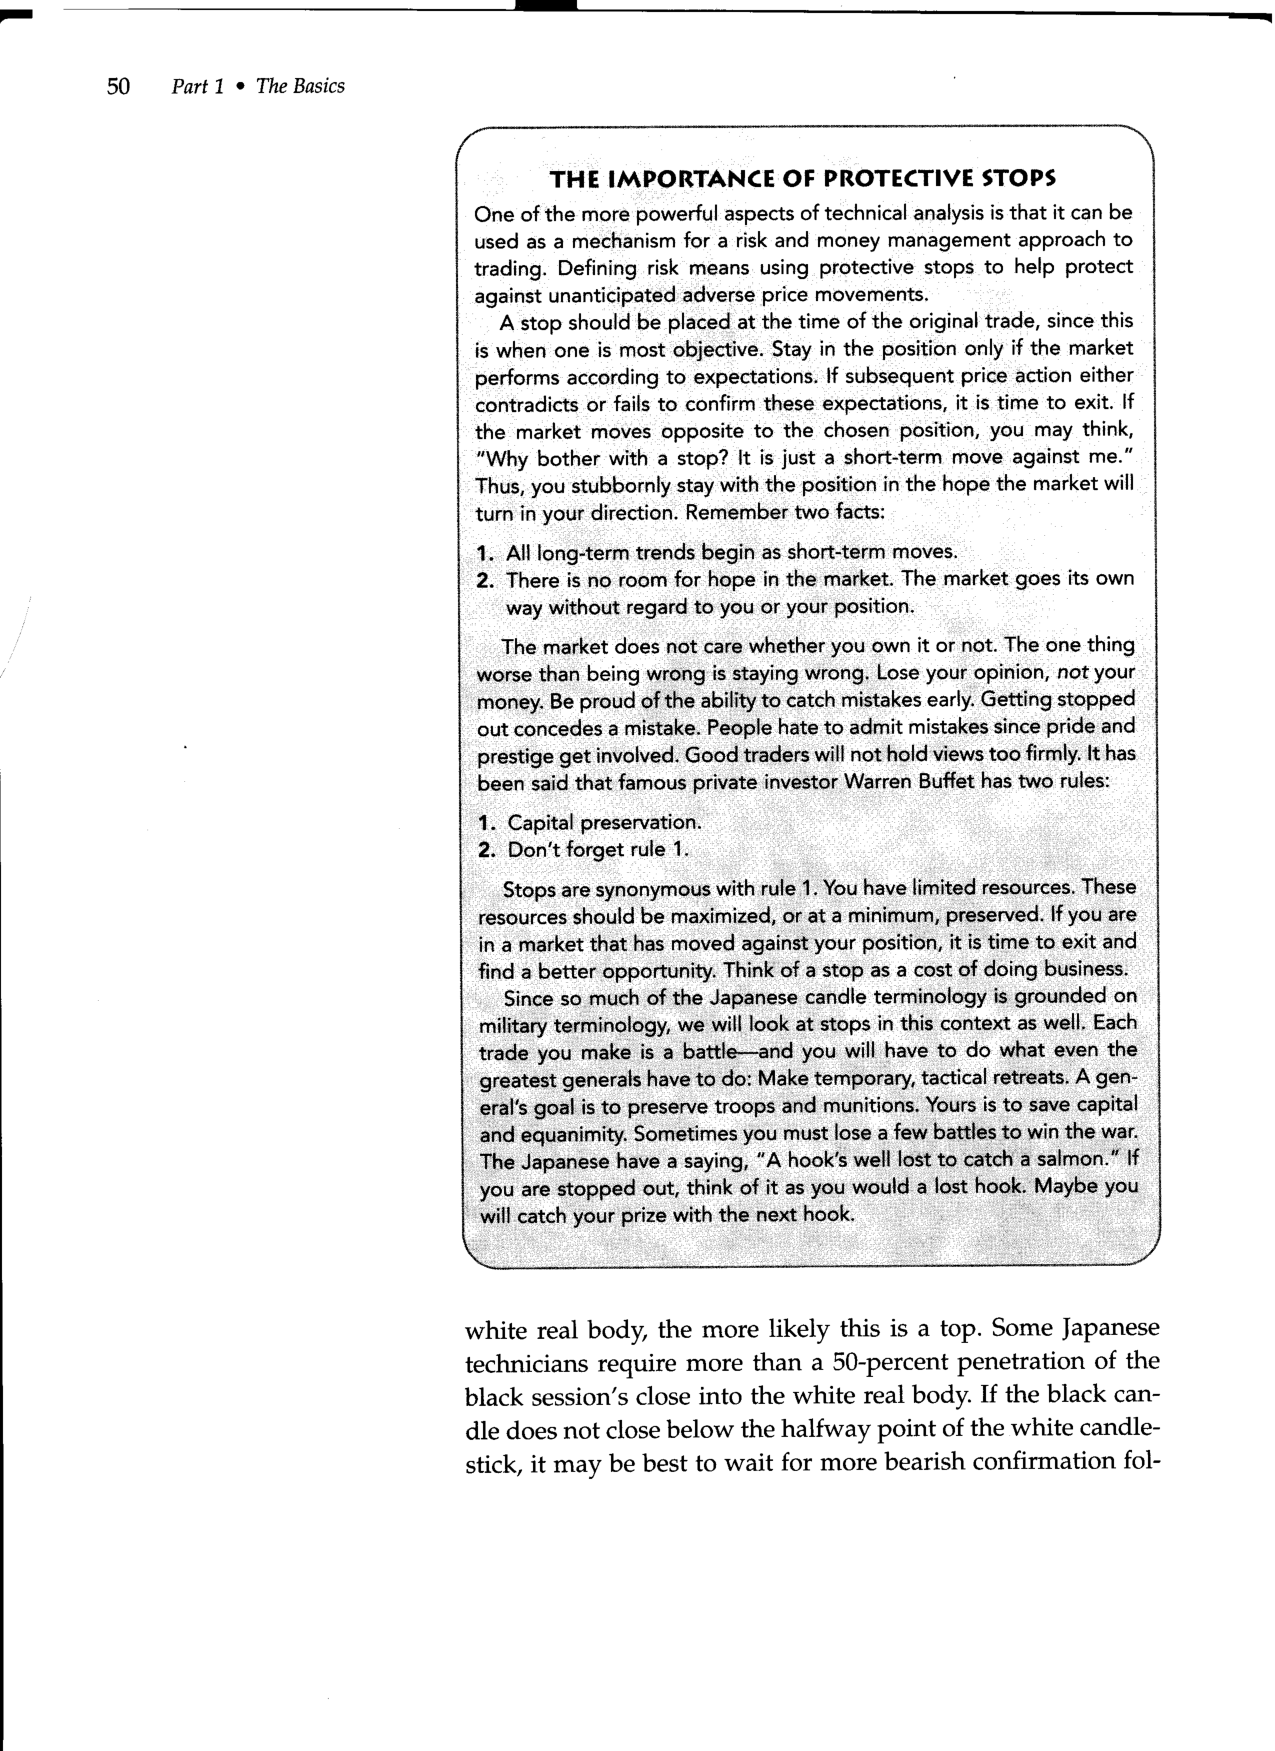

Page index 90 (viewer page 91)


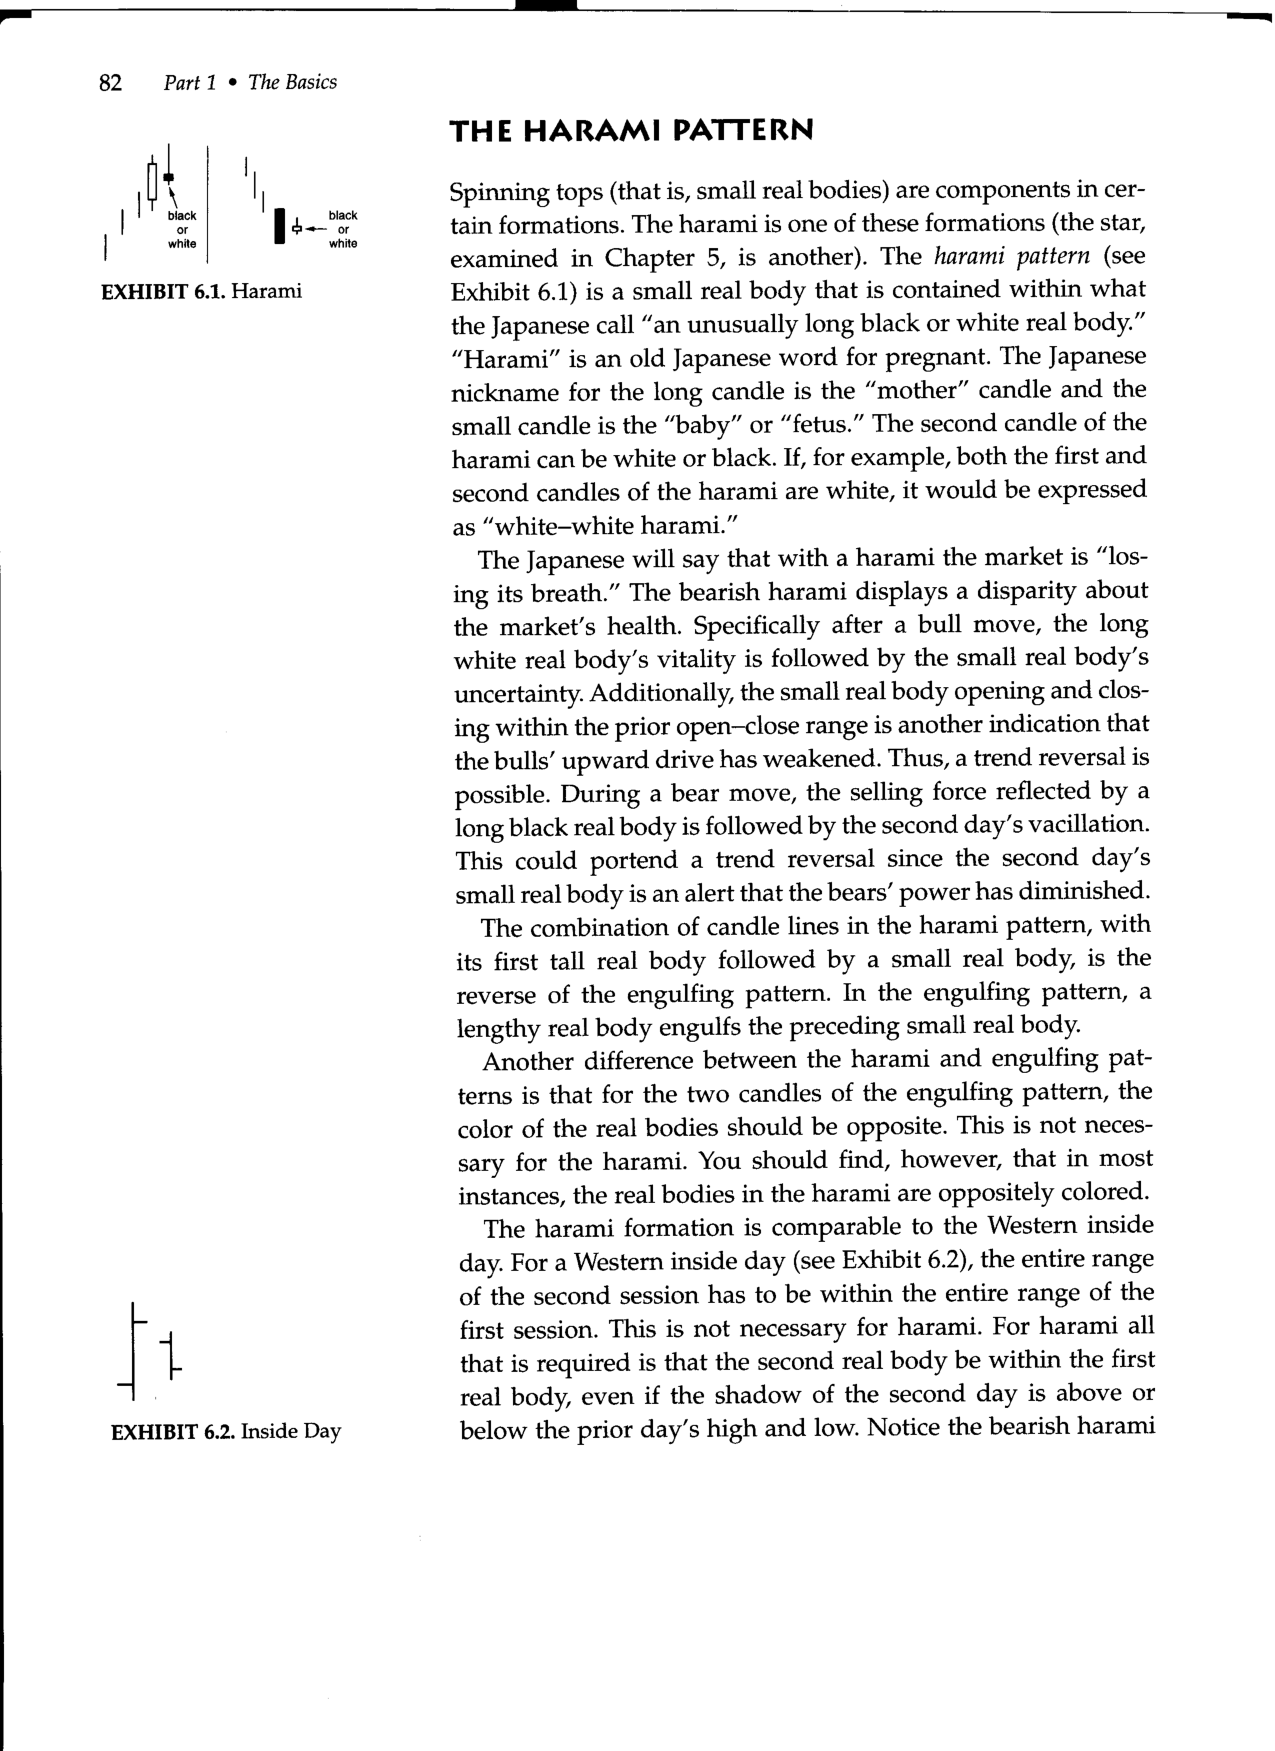

Page index 120 (viewer page 121)


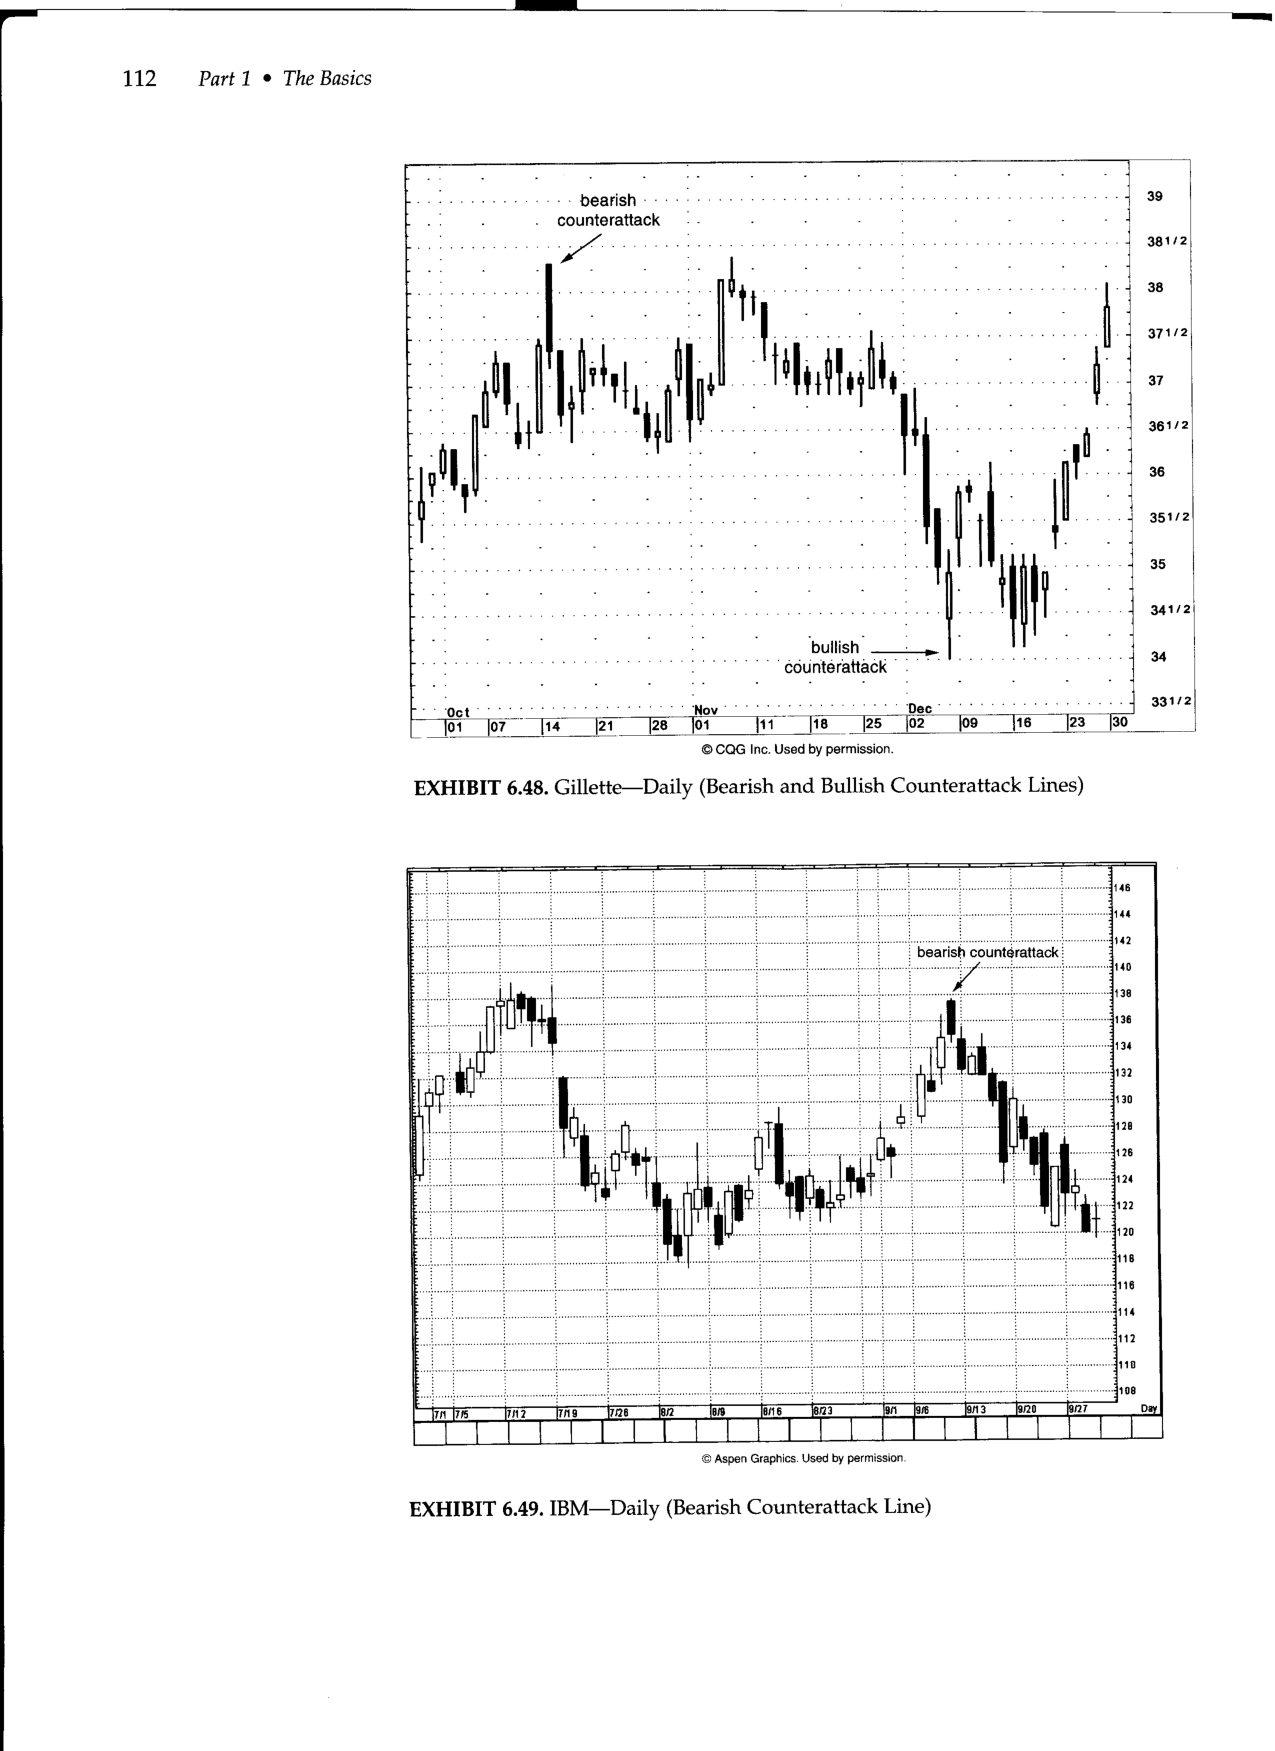

Page index 150 (viewer page 151)


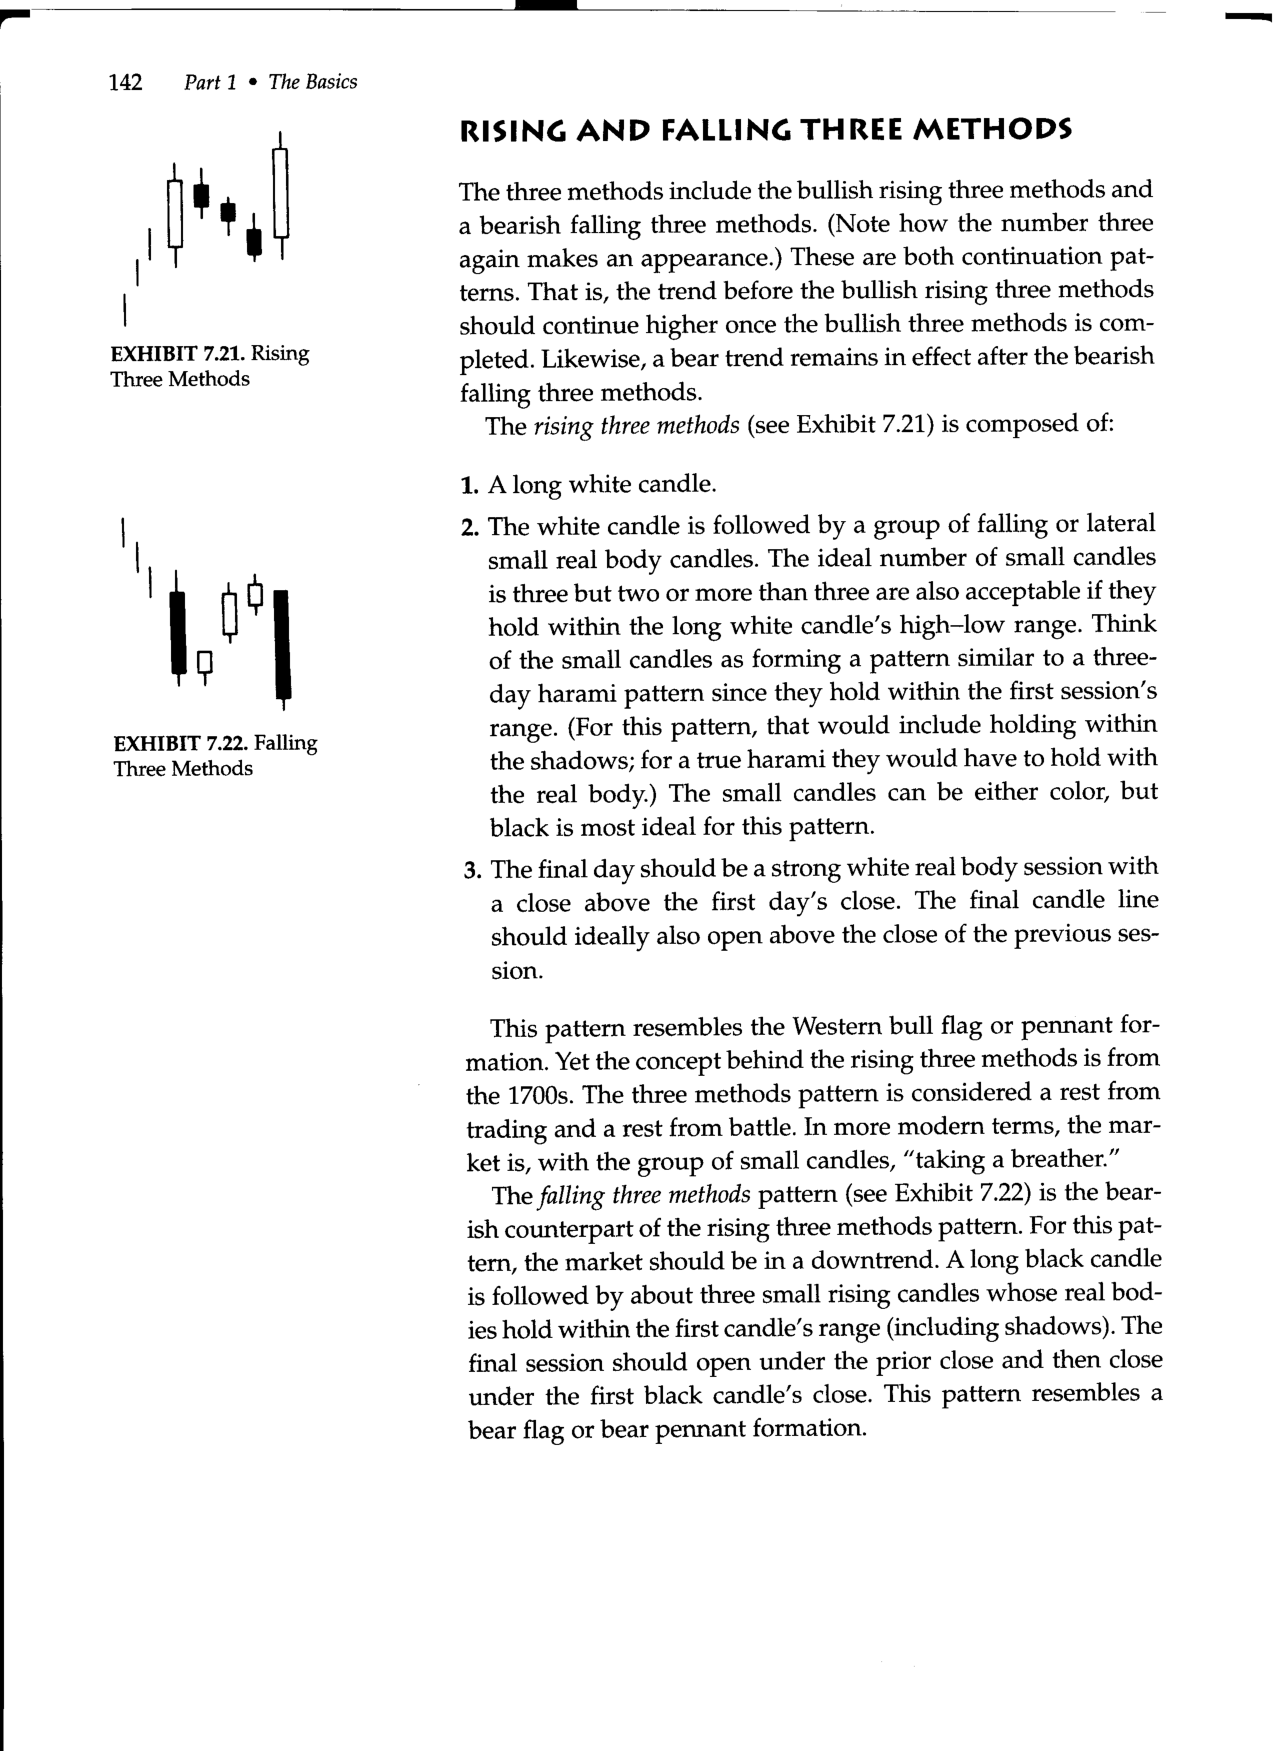

Page index 180 (viewer page 181)


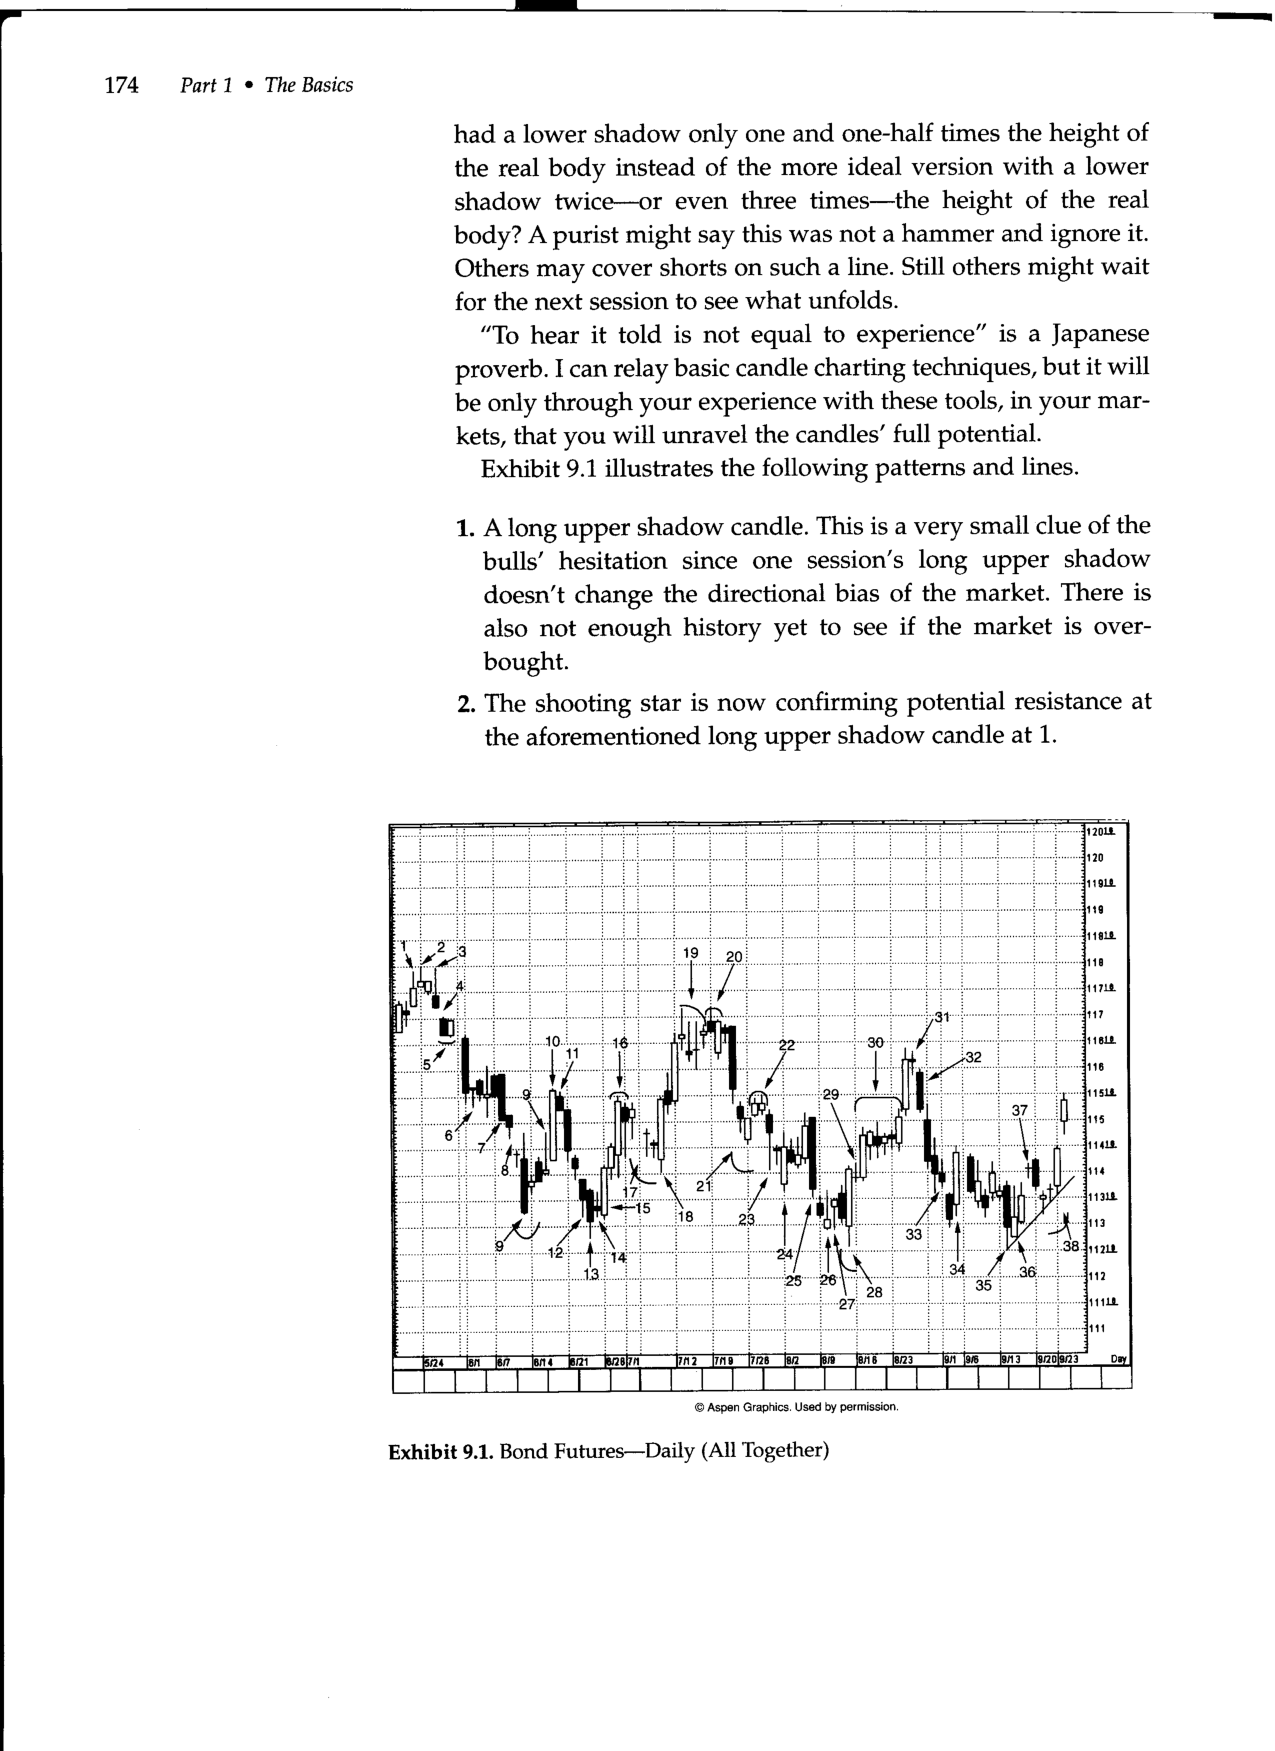

In [9]:
from PIL import Image
import io

doc = fitz.open("/content/drive/MyDrive/Colab Notebooks/Steve-Nison-Japanese-Candlestick-Charting-Techniques-Prentice-Hall-Press-2001.pdf")

# Render a spread of candidate pages to preview
candidate_pages = [60, 90, 120, 150, 180]

for idx in candidate_pages:
    pix = doc[idx].get_pixmap(dpi=150)
    img = Image.open(io.BytesIO(pix.tobytes("png")))
    print(f"Page index {idx} (viewer page {idx+1})")
    display(img)  # Colab renders PIL images inline with display()

In [10]:
def describe_image(pil_image, prompt="Describe this candlestick chart in detail: the pattern it illustrates, price trend direction, and any labeled annotations or captions."):
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": pil_image},
            {"type": "text", "text": prompt},
        ],
    }]
    text = vision_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = vision_processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(vision_model.device)
    generated_ids = vision_model.generate(**inputs, max_new_tokens=200)
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated_ids)]
    return vision_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

In [11]:
test_chart_page_index = 121

pix = doc[test_chart_page_index].get_pixmap(dpi=150)
chart_img = Image.open(io.BytesIO(pix.tobytes("png")))

description = describe_image(chart_img)
print(f"Page index: {test_chart_page_index} (viewer page {test_chart_page_index + 1})")
print(description)

KeyboardInterrupt: 

In [12]:
def build_documents(path, ocr_dpi=100, vision_dpi=150, max_pages=None, max_new_tokens=200):
    doc = fitz.open(path)
    documents = []
    n_pages = len(doc) if max_pages is None else min(max_pages, len(doc))

    for i in range(n_pages):
        page = doc[i]

        # Text OCR
        ocr_pix = page.get_pixmap(dpi=ocr_dpi)
        ocr_result = engine(ocr_pix.tobytes("png"))
        ocr_text = "\n".join(ocr_result.txts) if ocr_result and ocr_result.txts else ""

        # Vision description
        vis_pix = page.get_pixmap(dpi=vision_dpi)
        vis_img = Image.open(io.BytesIO(vis_pix.tobytes("png")))
        vision_desc = describe_image(vis_img)

        combined_text = f"{ocr_text}\n\n[Image/Chart Description]\n{vision_desc}"

        documents.append(Document(
            page_content=combined_text,
            metadata={"page": i, "source": path}
        ))

        if i % 10 == 0:
            print(f"Processed page {i}/{n_pages}")

    return documents

In [15]:
 import random
import time

def build_documents_for_pages(path, page_indices, ocr_dpi=100, vision_dpi=150):
    doc = fitz.open(path)
    documents = []

    for i in page_indices:
        page = doc[i]

        ocr_pix = page.get_pixmap(dpi=ocr_dpi)
        ocr_result = engine(ocr_pix.tobytes("png"))
        ocr_text = "\n".join(ocr_result.txts) if ocr_result and ocr_result.txts else ""

        vis_pix = page.get_pixmap(dpi=vision_dpi)
        vis_img = Image.open(io.BytesIO(vis_pix.tobytes("png")))
        vision_desc = describe_image(vis_img)

        combined_text = f"{ocr_text}\n\n[Image/Chart Description]\n{vision_desc}"

        documents.append(Document(
            page_content=combined_text,
            metadata={"page": i, "source": path}
        ))
        print(f"Done page {i}")

    return documents

In [ ]:
pdf_path = "/content/drive/MyDrive/Colab Notebooks/Steve-Nison-Japanese-Candlestick-Charting-Techniques-Prentice-Hall-Press-2001.pdf"

doc = fitz.open(pdf_path)
total_pages = len(doc)

random_pages = sorted(random.sample(range(20, total_pages), 5))  # skips front matter (first 20 pages)
print(f"Testing pages: {random_pages}")

start = time.time()
test_docs = build_documents_for_pages(pdf_path, random_pages)
elapsed = time.time() - start
print(f"\n{len(random_pages)} pages took {elapsed:.1f}s ({elapsed/len(random_pages):.1f}s/page)")

for d in test_docs:
    print(f"\n===== Page index {d.metadata['page']} (viewer page {d.metadata['page']+1}) =====")
    print(d.page_content[:600])
    print("...")

Testing pages: [90, 103, 187, 188, 271]


In [ ]:
import pickle
import os

def build_documents_full(path, ocr_dpi=100, vision_dpi=150, checkpoint_every=20, checkpoint_path="//content/drive/MyDrive/Colab Notebooks/ocr_checkpoint.pkl"): # You can change this to a Google Drive path, e.g., "/content/drive/MyDrive/ocr_checkpoint.pkl"
    doc = fitz.open(path)
    n_pages = len(doc)
    documents = []

    # Resume from checkpoint if one exists
    start_page = 0
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "rb") as f:
            documents = pickle.load(f)
        start_page = len(documents)
        print(f"Resuming from checkpoint: {start_page} pages already done.")

    for i in range(start_page, n_pages):
        try:
            page = doc[i]

            ocr_pix = page.get_pixmap(dpi=ocr_dpi)
            ocr_result = engine(ocr_pix.tobytes("png"))
            ocr_text = "\n".join(ocr_result.txts) if ocr_result and ocr_result.txts else ""

            vis_pix = page.get_pixmap(dpi=vision_dpi)
            vis_img = Image.open(io.BytesIO(vis_pix.tobytes("png")))
            vision_desc = describe_image(vis_img)

            combined_text = f"{ocr_text}\n\n[Image/Chart Description]\n{vision_desc}"

            documents.append(Document(
                page_content=combined_text,
                metadata={"page": i, "source": path}
            ))
        except Exception as e:
            print(f"Error on page {i}: {e}")
            documents.append(Document(
                page_content="",
                metadata={"page": i, "source": path, "error": str(e)}
            ))

        if (i + 1) % checkpoint_every == 0 or i == n_pages - 1:
            with open(checkpoint_path, "wb") as f:
                pickle.dump(documents, f)
            print(f"Checkpoint saved: {i+1}/{n_pages} pages done.")

    return documents

In [ ]:
pdf_path = "/content/drive/MyDrive/Colab Notebooks/Steve-Nison-Japanese-Candlestick-Charting-Techniques-Prentice-Hall-Press-2001.pdf"

documents = build_documents_full(pdf_path)
print(f"\nDone. Total documents: {len(documents)}")

### 2. Chunking and Embedding Documents

Now that we have processed the PDF into a list of `Document` objects (combining OCR text and image descriptions), the next step is to break these documents into smaller, manageable chunks. This is essential for efficient retrieval and to fit within the context window of Large Language Models.

After chunking, we will create numerical representations (embeddings) for each chunk and store them in a vector database (`Chroma`).

In [ ]:
!pip install langchain-text-splitters --break-system-packages -q

In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/Colab Notebooks/ocr_checkpoint.pkl"))

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(documents)

print(f"Original document has {len(documents)} pages. Split into {len(chunks)} chunks.")
print("Example chunk:")
print(chunks[0].page_content)
print("\nMetadata:", chunks[0].metadata)

In [ ]:
# Import necessary components for embeddings and vector store
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# Initialize embedding model
# Using a Sentence-BERT model from Hugging Face for creating embeddings.
# This model is locally runnable and does not require an API key.
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Create a Chroma vector database from the document chunks
# This will embed each chunk and store it, allowing for similarity searches.
# We'll persist the database to disk so it can be reloaded later if needed.
vectorstore = Chroma.from_documents(chunks, embeddings, persist_directory="./chroma_db")

print("Chroma vector database created successfully.")
print(f"Number of vectors in the database: {vectorstore._collection.count()}")
print("Vector database saved to disk in './chroma_db' directory.")

In [ ]:
# Load a pre-trained LLM model and tokenizer
# Using a small, efficient model for demonstration purposes
model_name = "google/gemma-2b-it"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16, # Use bfloat16 for potentially faster inference on compatible hardware
    device_map="auto"
)

# Create a text generation pipeline
pipe = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=tokenizer,
    max_new_tokens=500,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
    top_k=50,
    device=0 if device == 'cuda' else -1 # Use GPU (device 0) if available, otherwise CPU (-1)
)

llm = HuggingFacePipeline(pipeline=pipe)

print(f"LLM model '{model_name}' loaded and pipeline created.")

In [ ]:
from langchain.chains import RetrievalQA

# Create the RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",  # 'stuff' combines all retrieved documents into a single prompt
    retriever=retriever,
    return_source_documents=True
)

print("RAG chain created successfully. You can now use `qa_chain.run(\"Your question here\")` to query your documents.")

In [ ]:
# Query the RAG chain with the user's question
query = "What is an engulfing stick?"
response = qa_chain({"query": query})

print("Question:", query)
print("Answer:", response["result"])
print("\nSource Documents:")
for i, doc in enumerate(response["source_documents"]):
    print(f"Document {i+1} (page {doc.metadata.get('page')}):\n{doc.page_content}\n")

In [ ]:
if 'qa_chain' in locals() or 'qa_chain' in globals():
    print(f"qa_chain is defined and is of type: {type(qa_chain)}")
else:
    print("qa_chain is not defined.")